In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bbg_utils.bdh_mm import bdh_mm
from bbg_utils.bdp_mm import bdp_mm
cds_mappings = pd.read_csv(r"S:\Structured Credit\Matt Stuff\cds_mappings\cds_mappings_final.csv", encoding="cp1252")
cds_mappings.head(5)

,CDS_Curve_ID,CDS_Ticker,Markit_CDS_Ticker,Markit_ShortName,BB_5Y_CDS_ID,Markit_ParSpread_5Y,Markit_Currency,Markit_Doc_Clause,Markit_Seniority,BBG_5Y_CDS_Ticker,...,CDS_Corp_Ticker,CDS_Corp_Ticker_Ovrd,CDS_Corp_Ticker_Final,BBG_Equity_Ticker,Eq_Ticker_Company_Name,Company_Private,Ultimate_Parent_Equity_Ticker,Ultimate_Parent_Private,Markit_Ticker_Lookup_BBG_RedCode,Markit_Ticker_Mismatch
0,1,AAL,AMERAIAI,Amern Airls Group Inc,CAMR1U5,363.3052,USD,XR14,SNRFOR,AMR/AMERICAN CDS USD SR 5Y D14 Corp,...,AAL,NaN,AAL,AAL US Equity,AMERICAN AIRLINES GROUP INC,N,AAL US Equity,N,AMERAIAI,NaN
1,2,ADT,THADT,ADT SEC CORP,CY325664,124.1882,USD,XR14,SNRFOR,ADT CDS USD SR 5Y D14 Corp,...,ADT,NaN,ADT,1566019D US Equity,ADT SECURITY CORP/THE,Y,ADT US Equity,N,THADT,NaN
2,3,ALIANT,ALLIHOAH,ALLIANT HLDGS INTERLLC,CY907103,266.2280,USD,XR14,SNRFOR,CY907103 Curncy,...,#N/A Field Not Applicable,ALIANT,ALIANT,1426133D US Equity,ALLIANT HOLDINGS INTERMEDIAT,Y,1339681D US Equity,Y,ALLIHOAH,NaN
3,4,AMKR,AMKR,Amkor Tech Inc,CT356410,104.9897,USD,XR14,SNRFOR,AMKR CDS USD SR 5Y D14 Corp,...,AMKR,NaN,AMKR,AMKR US Equity,AMKOR TECHNOLOGY INC,N,AMKR US Equity,N,AMKR,NaN
4,5,ARMK,ARAMSER,Aramark Service In,CT371596,85.7218,USD,XR14,SNRFOR,ARMK CDS USD SR 5Y D14 Corp,...,ARMK,NaN,ARMK,2387Z US Equity,ARAMARK SERVICES INC,Y,ARMK US Equity,N,ARAMSER,NaN


In [ ]:
from databricks_utils import get_delta_table_mm

CACHE_DIR = r"S:\Structured Credit\Matt Stuff\claude_repos\cds_bond_basis\cache"

CDS_TRANSFORM_COLUMNS = [
    "published_date",
    "market_cds_ticker",
    "tenor",
    "cds_maturity",
    "cds_index",
    "tier",
    "currency",
    "doc_clause",
    "running_coupon",
    "par_spread",
    "conv_spread",
    "upfront",
    "cds_assumed_recovery",
    "all_upfront",
]

cds_transform_interpolated = get_delta_table_mm(
    "teams.structured_credit_abhutra.cds_transform_interpolated",
    cache_dir=CACHE_DIR,
    columns=CDS_TRANSFORM_COLUMNS,
    where="published_date >= '2025-01-01'",
    filename="cds_transform_interpolated_subset_2025.parquet",
)

[cache] cds_transform_interpolated_subset_2025.parquet is current — loading from disk


In [ ]:
print(cds_transform_interpolated.shape)
cds_transform_interpolated.head(5)

(3719525, 14)


,published_date,market_cds_ticker,tenor,cds_maturity,cds_index,tier,currency,doc_clause,running_coupon,par_spread,conv_spread,upfront,cds_assumed_recovery,all_upfront
0,2026-07-21,ARGID,6M,2026-12-20,XO_Legacy,SNRFOR,EUR,MM14,500.0,724.4308,724.6658,0.9176,0.4,2.9676
1,2026-07-21,ARGID,1Y,2027-06-20,XO_Legacy,SNRFOR,EUR,MM14,500.0,938.3771,943.2733,3.7742,0.4,8.0742
2,2026-07-21,ARGID,1Y6M,2027-12-20,XO_Legacy,SNRFOR,EUR,MM14,500.0,898.0091,901.4532,5.0149,0.4,11.3149
3,2026-07-21,ARGID,2Y,2028-06-20,XO_Legacy,SNRFOR,EUR,MM14,500.0,857.6411,859.6331,5.9454,0.4,14.2454
4,2026-07-21,ARGID,2Y6M,2028-12-20,XO_Legacy,SNRFOR,EUR,MM14,500.0,867.0567,870.6940,7.3411,0.4,17.3411


In [ ]:
cds_mappings_filtered = (
    cds_mappings
    .dropna(subset=["Best_Bond_Proxy_ISIN"])
    [["CDS_Ticker", "CDS_Index", "Best_Bond_Proxy_ISIN", "Markit_ShortName"]]
    .rename(columns={"CDS_Ticker": "ticker", "CDS_Index": "cds_index", "Best_Bond_Proxy_ISIN": "BOND_ISIN"})
    .reset_index(drop=True)
)
print(cds_mappings_filtered.shape)
cds_mappings_filtered.head(5)

(372, 4)


,ticker,cds_index,BOND_ISIN,Markit_ShortName
0,AAL,HY,US023771T329,Amern Airls Group Inc
1,ADT,HY,US74166NAA28,ADT SEC CORP
2,ALIANT,HY,US01883LAH69,ALLIANT HLDGS INTERLLC
3,AMKR,HY,US031652BL34,Amkor Tech Inc
4,ARMK,HY,XS3023482436,Aramark Service In


In [ ]:
bonds = cds_mappings_filtered.copy()
bonds["security"] = bonds["BOND_ISIN"] + " Corp"

bond_history = bdh_mm(
    bonds["security"],
    ["LAST_PRICE", "BLP_SPRD_TO_BENCH_MID", "BLOOMBERG_MID_G_SPREAD"],
    start_date="2025-01-01",
)
print(bond_history.shape)
bond_history.head(5)

(119404, 5)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD
0,BE6364524635 Corp,2026-07-22,98.308,66.346,65.552
1,DE000A4DFLQ6 Corp,2026-07-22,104.104,146.451,143.732
2,FI4000590864 Corp,2026-07-22,96.268,188.203,183.344
3,FR0011270487 Corp,2026-07-22,84.828,430.858,430.922
4,FR0014004R72 Corp,2026-07-22,88.384,81.679,78.745


In [ ]:
bond_maturity = bdp_mm(bonds["security"], ["MATURITY", "SECURITY_NAME"])
bond_maturity["MATURITY"] = pd.to_datetime(bond_maturity["MATURITY"])
bond_maturity.head(5)

,security,MATURITY,SECURITY_NAME
0,BBG01K579GK6 Corp,2028-11-30,EGBLFN Float 11/30/28
1,BE6364524635 Corp,2033-05-19,ABIBB 3 3/8 05/19/33
2,DE000A4DFLQ6 Corp,2031-04-01,SHAEFF 5 3/8 04/01/31
3,FI4000590864 Corp,2031-05-28,METSA 3 7/8 05/28/31
4,FR0011270487 Corp,2032-06-14,FTI 4 06/14/32


In [ ]:
from datetime import date

def next_cds_maturity(maturity):
    """First standard semi-annual CDS maturity (20-Jun or 20-Dec) strictly after `maturity`."""
    maturity = pd.Timestamp(maturity).date()
    candidates = sorted(
        date(y, m, 20)
        for y in (maturity.year, maturity.year + 1)
        for m in (6, 12)
    )
    return next(c for c in candidates if c > maturity)

bond_maturity["target_cds_maturity"] = bond_maturity["MATURITY"].apply(next_cds_maturity)

bond_history = bond_history.merge(bond_maturity, on="security", how="left")
bond_history = bond_history.merge(bonds[["security", "ticker", "cds_index", "Markit_ShortName"]], on="security", how="left")

print(bond_history.shape)
bond_history.head(5)

(119404, 11)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,Markit_ShortName
0,BE6364524635 Corp,2026-07-22,98.308,66.346,65.552,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,AnheuserBusch InBev
1,DE000A4DFLQ6 Corp,2026-07-22,104.104,146.451,143.732,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,Schaeffler AG
2,FI4000590864 Corp,2026-07-22,96.268,188.203,183.344,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,Metsa Brd Corp
3,FR0011270487 Corp,2026-07-22,84.828,430.858,430.922,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,XO_Legacy,TechnipFMC PLC
4,FR0014004R72 Corp,2026-07-22,88.384,81.679,78.745,2030-07-27,ALOFP 0 1/2 07/27/30,2030-12-20,ALOFP,Main,ALSTOM


In [ ]:
bond_history = bond_history.merge(
    cds_transform_interpolated[["market_cds_ticker", "published_date", "cds_maturity", "conv_spread", "upfront"]],
    left_on=["ticker", "date", "target_cds_maturity"],
    right_on=["market_cds_ticker", "published_date", "cds_maturity"],
    how="left",
).drop(columns=["market_cds_ticker", "published_date", "cds_maturity"])

print(bond_history.shape)
bond_history.head(5)

(119404, 13)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,Markit_ShortName,conv_spread,upfront
0,BE6364524635 Corp,2026-07-22,98.308,66.346,65.552,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,AnheuserBusch InBev,NaN,NaN
1,DE000A4DFLQ6 Corp,2026-07-22,104.104,146.451,143.732,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,Schaeffler AG,NaN,NaN
2,FI4000590864 Corp,2026-07-22,96.268,188.203,183.344,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,Metsa Brd Corp,NaN,NaN
3,FR0011270487 Corp,2026-07-22,84.828,430.858,430.922,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,XO_Legacy,TechnipFMC PLC,NaN,NaN
4,FR0014004R72 Corp,2026-07-22,88.384,81.679,78.745,2030-07-27,ALOFP 0 1/2 07/27/30,2030-12-20,ALOFP,Main,ALSTOM,NaN,NaN


In [ ]:
cds_5y = (
    cds_transform_interpolated[cds_transform_interpolated["tenor"] == "5Y"]
    [["market_cds_ticker", "published_date", "conv_spread"]]
    .rename(columns={"conv_spread": "cds_spread_5y"})
)

bond_history = bond_history.merge(
    cds_5y,
    left_on=["ticker", "date"],
    right_on=["market_cds_ticker", "published_date"],
    how="left",
).drop(columns=["market_cds_ticker", "published_date"])

print(bond_history.shape)
bond_history.head(5)

(119404, 14)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,Markit_ShortName,conv_spread,upfront,cds_spread_5y
0,BE6364524635 Corp,2026-07-22,98.308,66.346,65.552,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,AnheuserBusch InBev,NaN,NaN,NaN
1,DE000A4DFLQ6 Corp,2026-07-22,104.104,146.451,143.732,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,Schaeffler AG,NaN,NaN,NaN
2,FI4000590864 Corp,2026-07-22,96.268,188.203,183.344,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,Metsa Brd Corp,NaN,NaN,NaN
3,FR0011270487 Corp,2026-07-22,84.828,430.858,430.922,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,XO_Legacy,TechnipFMC PLC,NaN,NaN,NaN
4,FR0014004R72 Corp,2026-07-22,88.384,81.679,78.745,2030-07-27,ALOFP 0 1/2 07/27/30,2030-12-20,ALOFP,Main,ALSTOM,NaN,NaN,NaN


In [ ]:
bond_history["basis_spread"] =  bond_history["conv_spread"] - bond_history["BLOOMBERG_MID_G_SPREAD"]
bond_history["basis_price"] =  bond_history["upfront"] + bond_history["LAST_PRICE"]
bond_history = bond_history.rename(columns={
    "BLP_SPRD_TO_BENCH_MID":"Benchmark_Spread",
    "BLOOMBERG_MID_G_SPREAD":"G_Spread",
    "conv_spread":"cds_spread",
})

bond_history.head(5)

,security,date,LAST_PRICE,Benchmark_Spread,G_Spread,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,Markit_ShortName,cds_spread,upfront,cds_spread_5y,basis_spread,basis_price
0,BE6364524635 Corp,2026-07-22,98.308,66.346,65.552,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,AnheuserBusch InBev,NaN,NaN,NaN,NaN,NaN
1,DE000A4DFLQ6 Corp,2026-07-22,104.104,146.451,143.732,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,Schaeffler AG,NaN,NaN,NaN,NaN,NaN
2,FI4000590864 Corp,2026-07-22,96.268,188.203,183.344,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,Metsa Brd Corp,NaN,NaN,NaN,NaN,NaN
3,FR0011270487 Corp,2026-07-22,84.828,430.858,430.922,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,XO_Legacy,TechnipFMC PLC,NaN,NaN,NaN,NaN,NaN
4,FR0014004R72 Corp,2026-07-22,88.384,81.679,78.745,2030-07-27,ALOFP 0 1/2 07/27/30,2030-12-20,ALOFP,Main,ALSTOM,NaN,NaN,NaN,NaN,NaN


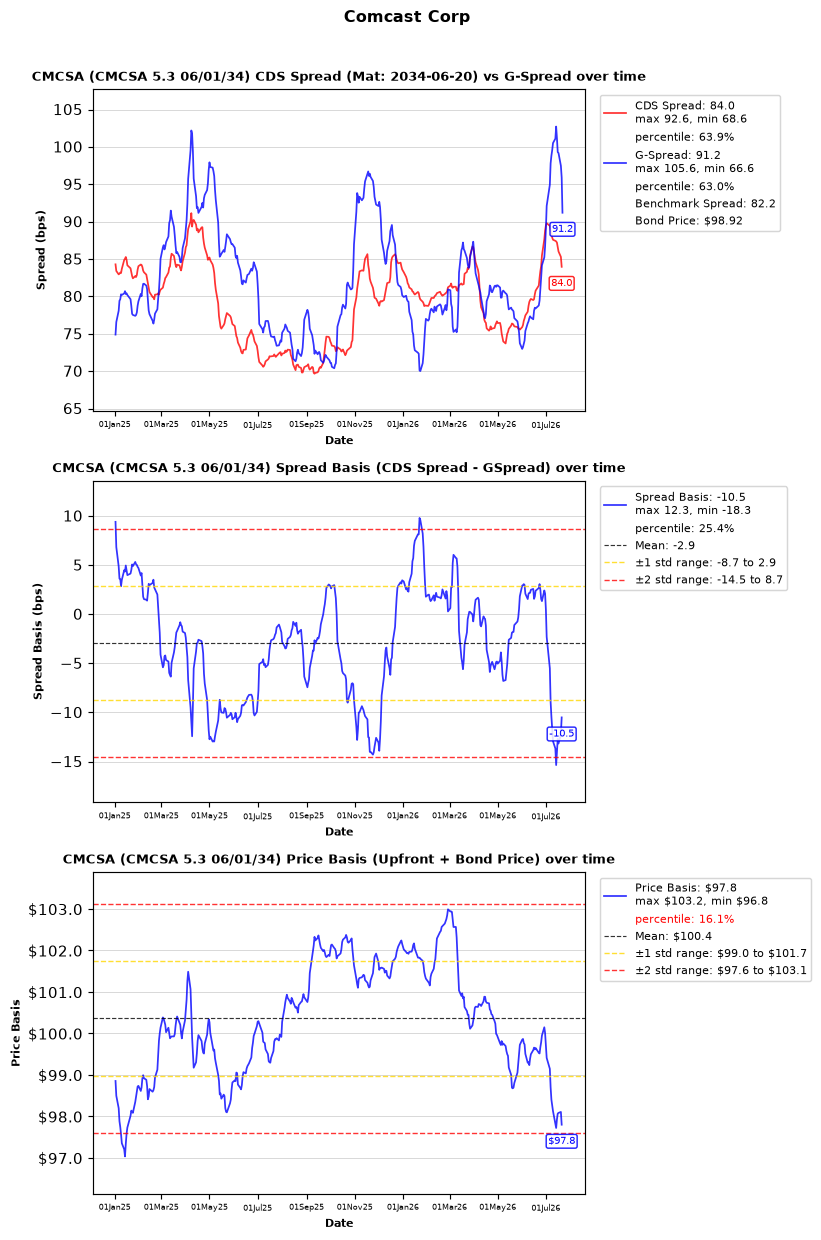

In [ ]:
import sys
from pathlib import Path

# ── Locate project root and register the slideshow package ────────────────────
# Works whether the kernel CWD is notebooks/ or the project root.
for _candidate in [Path.cwd(), Path.cwd().parent]:
    if (_candidate / "slideshow" / "__init__.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from slideshow.plotting import plot_bond_cds_basis
from slideshow_utils    import run_slideshow
from IPython.display import Image

TICKER_TO_PLOT = "CMCSA"

_, img_bytes = plot_bond_cds_basis(TICKER_TO_PLOT, bond_history)
display(Image(data=img_bytes))

#### Slideshow

In [ ]:
CDS_INDEX_TO_PLOT = "IG"  # set to None to include all indices

ticker_index_df = (
    bond_history[["ticker", "cds_index"]]
    .dropna(subset=["ticker"])
    .drop_duplicates()
    .sort_values(["cds_index", "ticker"])
    .reset_index(drop=True)
)

ticker_list = (
    ticker_index_df[ticker_index_df["cds_index"] == CDS_INDEX_TO_PLOT]["ticker"].tolist()
    if CDS_INDEX_TO_PLOT is not None
    else ticker_index_df["ticker"].tolist()
)
len(ticker_list)

125

In [ ]:
START_TICKER = ''  # set to a ticker (e.g. "ORCL") to resume the slideshow from there

run_slideshow(
    items      = ticker_list,
    render_fn  = lambda t: plot_bond_cds_basis(t, bond_history),
    timer_secs = 5,
    start_item = START_TICKER,
)

Output()